In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# masukkan data
diamonds_df = sns.load_dataset("diamonds")
sample_df = diamonds_df.sample(n=1000, random_state=42)
correlation_matrix = diamonds_df.corr(numeric_only=True)

In [3]:
# atur tema dan konteks
sns.set_theme(style="whitegrid", context="talk", palette="viridis")

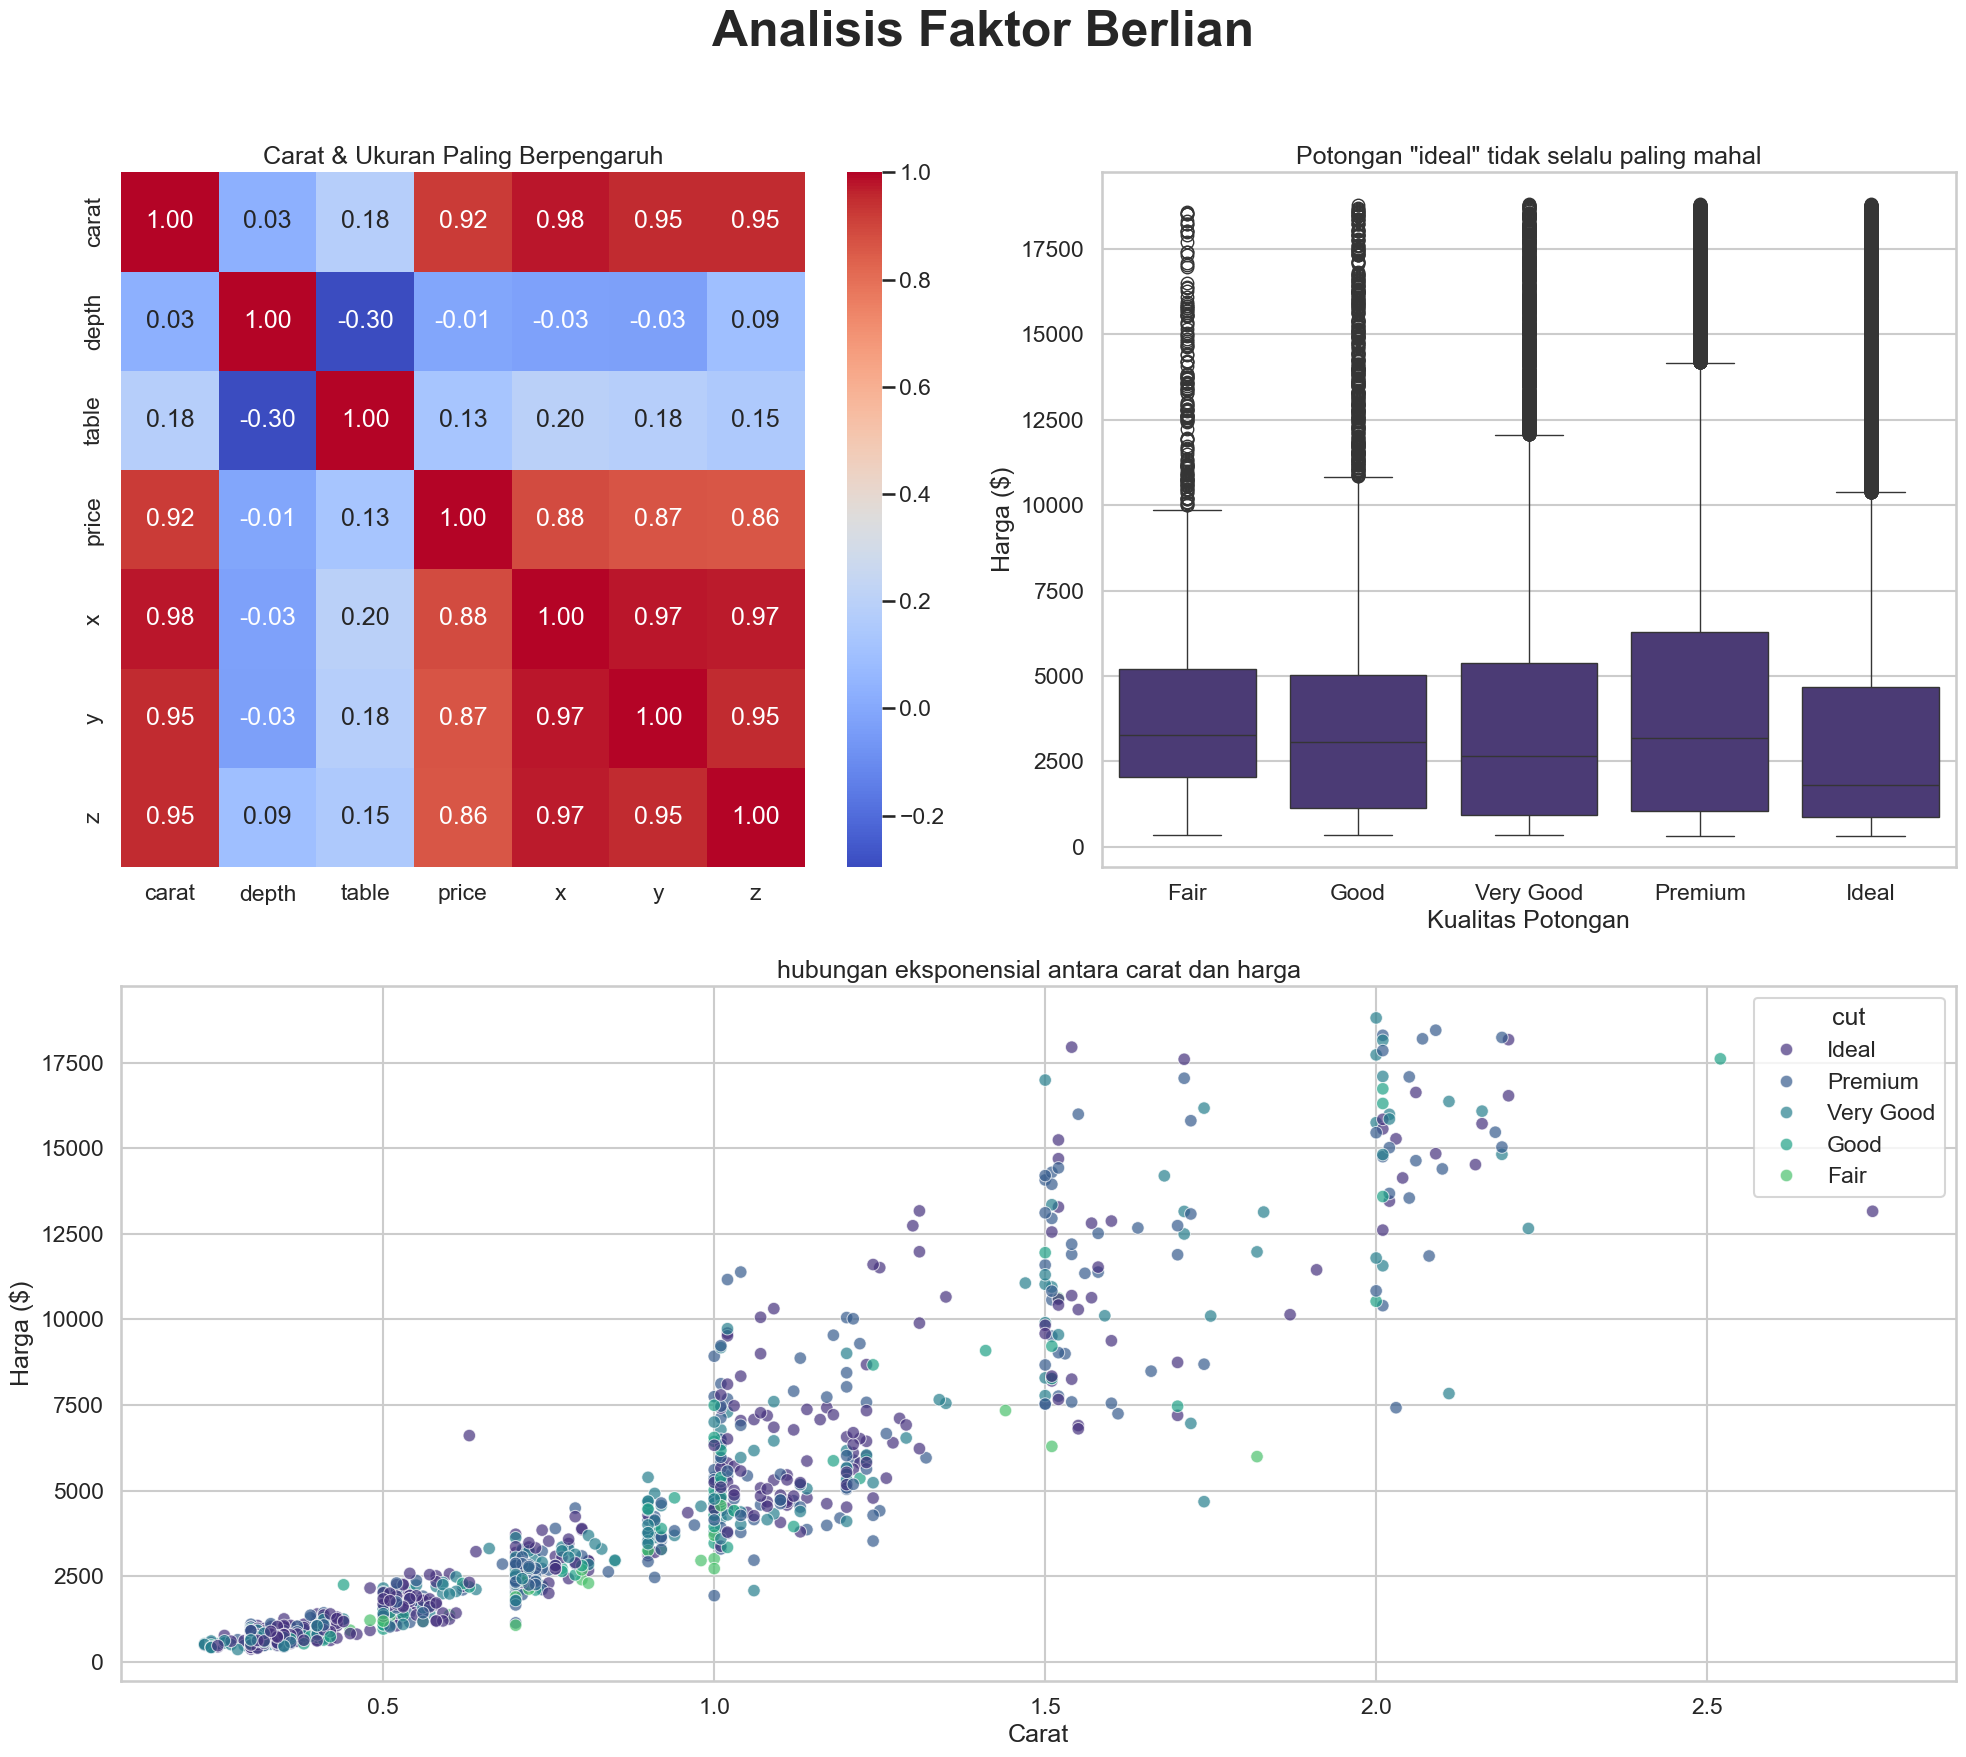

In [22]:
# membuat kanvas 2x2
fig, axes = plt.subplots(2,2,figsize=(20,18))

# Judul utama
fig.suptitle("Analisis Faktor Berlian", fontsize=36, fontweight='bold')

# plot 1: heatmap korelasi (axes=(0,0))
sns.heatmap(
    ax=axes[0,0],
    data=correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
    )
axes[0,0].set_title("Carat & Ukuran Paling Berpengaruh", fontsize=18)

# Plot 2: distribusi harga vs kualitas hubungan (axes(0,1))
sns.boxplot(
    ax=axes[0,1],
    data=diamonds_df,
    x='cut',
    y='price',
    order=['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
    )
axes[0,1].set_title('Potongan "ideal" tidak selalu paling mahal', fontsize=18)
axes[0,1].set_xlabel('Kualitas Potongan')
axes[0,1].set_ylabel('Harga ($)')

# plot 3: hubungan utama carat vs price (Axes [1,0] & Axes [1,1])

gs = axes[0,1].get_gridspec()

for ax in axes[1,:]:
    ax.remove()

ax_bottom = fig.add_subplot(gs[1,:])

sns.scatterplot(
    ax=ax_bottom,
    data=sample_df,
    x='carat',
    y='price',
    hue='cut',
    alpha=0.7
    )
ax_bottom.set_title("hubungan eksponensial antara carat dan harga", fontsize=18)
ax_bottom.set_xlabel("Carat")
ax_bottom.set_ylabel("Harga ($)")

# Merapikan Layout
plt.tight_layout(rect=[0,0,1,0.96])
plt.show()